# Análisis Global de Clima y Energía 2020–2024
## Paso 1: Exploración y limpieza del dataset

**Autor:** Miguel Sierra  
**Dataset:** 20 países · 5 años · 10 variables · 36,540 registros  
**Objetivo:** Entender la estructura del dato, detectar problemas de calidad y preparar el dataset para el análisis.

In [11]:
# Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Librería para visualizar valores nulos
import missingno as msno

# Configuraciones globales de visualización
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [12]:
# Cargamos el CSV desde la carpeta data/
df = pd.read_csv("../data/global_climate_energy_2020_2024.csv", parse_dates=["date"])

# Confirmación de carga
print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

✅ Dataset cargado: 36,540 filas × 10 columnas


In [13]:
# Ver las primeras 5 filas
display(df.head())

# Ver las últimas 5 filas
display(df.tail())

,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
0,2020-01-01,Germany,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93
1,2020-01-02,Germany,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40
2,2020-01-03,Germany,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58
3,2020-01-04,Germany,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13
4,2020-01-05,Germany,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60


,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
36535,2024-12-27,Indonesia,10.91,85.88,134.23,6607.39,22.04,69.43,76.38,160.33
36536,2024-12-28,Indonesia,10.91,65.14,366.68,4654.41,23.79,62.66,43.33,58.49
36537,2024-12-29,Indonesia,10.91,66.33,256.12,1982.89,14.92,77.53,76.67,148.77
36538,2024-12-30,Indonesia,10.91,39.18,251.60,2689.54,21.66,62.92,72.84,153.20
36539,2024-12-31,Indonesia,10.91,54.24,444.88,6227.33,22.28,73.13,66.80,185.53


In [14]:
print("=" * 55)
print("ESTRUCTURA DEL DATASET")
print("=" * 55)
print(f"\n  Filas:    {df.shape[0]:,}")
print(f"  Columnas: {df.shape[1]}")
print(f"\n  Rango de fechas: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Países:   {df['country'].nunique()} ({', '.join(sorted(df['country'].unique()))})")
print(f"\n  Registros por país:")
for pais, n in df['country'].value_counts().sort_index().items():
    print(f"    {pais:<20} {n:,} registros")

ESTRUCTURA DEL DATASET

  Filas:    36,540
  Columnas: 10

  Rango de fechas: 2020-01-01 → 2024-12-31
  Países:   20 (Australia, Brazil, Canada, China, France, Germany, India, Indonesia, Italy, Japan, Mexico, Netherlands, Norway, Poland, South Africa, Spain, Sweden, Turkey, United Kingdom, United States)

  Registros por país:
    Australia            1,827 registros
    Brazil               1,827 registros
    Canada               1,827 registros
    China                1,827 registros
    France               1,827 registros
    Germany              1,827 registros
    India                1,827 registros
    Indonesia            1,827 registros
    Italy                1,827 registros
    Japan                1,827 registros
    Mexico               1,827 registros
    Netherlands          1,827 registros
    Norway               1,827 registros
    Poland               1,827 registros
    South Africa         1,827 registros
    Spain                1,827 registros
    Sweden     

In [15]:
print("=" * 55)
print("TIPOS DE DATOS POR COLUMNA")
print("=" * 55)
display(df.dtypes.to_frame(name="tipo").rename_axis("columna"))

TIPOS DE DATOS POR COLUMNA


,tipo
columna,
date,datetime64[us]
country,str
avg_temperature,float64
humidity,float64
co2_emission,float64
energy_consumption,float64
renewable_share,float64
urban_population,float64
industrial_activity_index,float64


In [16]:
print("=" * 55)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 55)

nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"nulos": nulos, "porcentaje (%)": pct})
display(resumen_nulos)

if nulos.sum() == 0:
    print("\n✅ El dataset no tiene valores nulos. ¡Excelente calidad de dato!")
else:
    print(f"\n⚠️  Se detectaron {nulos.sum()} valores nulos en total.")

ANÁLISIS DE VALORES NULOS


,nulos,porcentaje (%)
date,0,0.0
country,0,0.0
avg_temperature,0,0.0
humidity,0,0.0
co2_emission,0,0.0
energy_consumption,0,0.0
renewable_share,0,0.0
urban_population,0,0.0
industrial_activity_index,0,0.0
energy_price,0,0.0



✅ El dataset no tiene valores nulos. ¡Excelente calidad de dato!


In [17]:
print("=" * 55)
print("ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS")
print("=" * 55)

desc = df.describe().T
desc.columns = ["count","mean","std","min","25%","50%","75%","max"]
desc = desc.drop(columns=["count"])
desc = desc.round(2)
display(desc)

ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS


,mean,std,min,25%,50%,75%,max
date,2022-07-02 00:00:00,2020-01-01 00:00:00,2021-04-01 00:00:00,2022-07-02 00:00:00,2023-10-02 00:00:00,2024-12-31 00:00:00,NaN
avg_temperature,13.580868,-9.6,5.63,13.79,20.84,38.71,10.077249
humidity,59.971469,30.0,45.01,59.99,74.97,90.0,17.303103
co2_emission,445.820452,50.15,248.675,422.655,628.4225,999.85,234.360906
energy_consumption,7295.904857,1001.89,4184.1775,6921.62,10175.11,15998.05,3693.928504
renewable_share,15.94408,5.0,12.02,15.715,19.84,30.87,5.334804
urban_population,74.982156,60.0,67.47,75.03,82.5025,90.0,8.6454
industrial_activity_index,70.173094,40.0,55.3,70.055,85.26,100.0,17.334816
energy_price,115.279848,30.0,72.42,115.24,158.27,200.0,49.178361


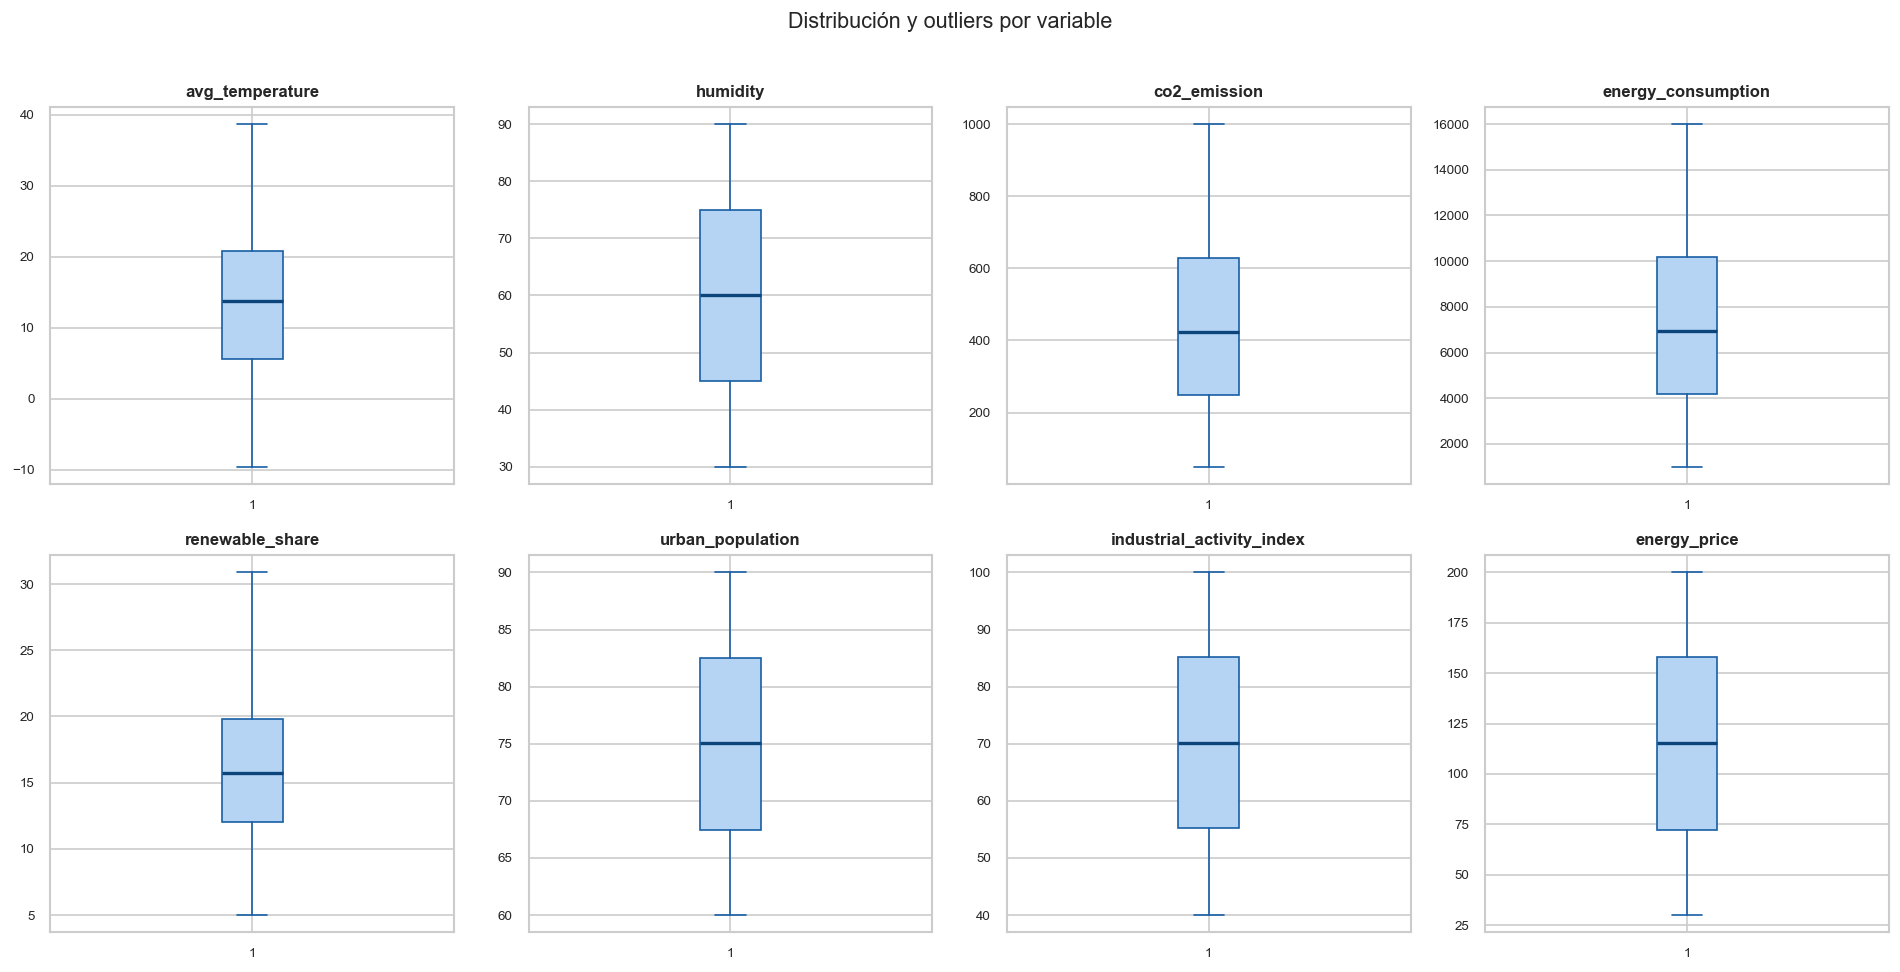

In [18]:
variables_numericas = [
    "avg_temperature", "humidity", "co2_emission",
    "energy_consumption", "renewable_share",
    "urban_population", "industrial_activity_index", "energy_price"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
                    medianprops=dict(color="#0C447C", linewidth=2),
                    whiskerprops=dict(color="#185FA5"),
                    capprops=dict(color="#185FA5"),
                    flierprops=dict(marker="o", color="#E24B4A", markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].tick_params(axis="both", labelsize=8)

plt.suptitle("Distribución y outliers por variable", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
fig = px.box(
    df, x="country", y="avg_temperature", color="country",
    title="Distribución de temperatura promedio por país (2020–2024)",
    labels={"avg_temperature": "Temperatura (°C)", "country": "País"},
    height=500
)
fig.update_layout(showlegend=False, xaxis_tickangle=-35)
fig.show()

In [20]:
co2_tiempo = df.groupby("date")["co2_emission"].mean().reset_index()

fig = px.line(
    co2_tiempo, x="date", y="co2_emission",
    title="Evolución de emisiones de CO₂ promedio global (2020–2024)",
    labels={"co2_emission": "CO₂ promedio", "date": "Fecha"},
    height=400
)
fig.update_traces(line_color="#E24B4A", line_width=1.5)
fig.show()

In [21]:
renovables = (
    df.groupby("country")["renewable_share"]
    .mean()
    .reset_index()
    .sort_values("renewable_share", ascending=True)
)

fig = px.bar(
    renovables, x="renewable_share", y="country",
    orientation="h",
    title="Participación promedio de energías renovables por país (2020–2024)",
    labels={"renewable_share": "% Renovable promedio", "country": "País"},
    color="renewable_share",
    color_continuous_scale="Teal",
    height=550
)
fig.update_layout(coloraxis_showscale=False)
fig.show()

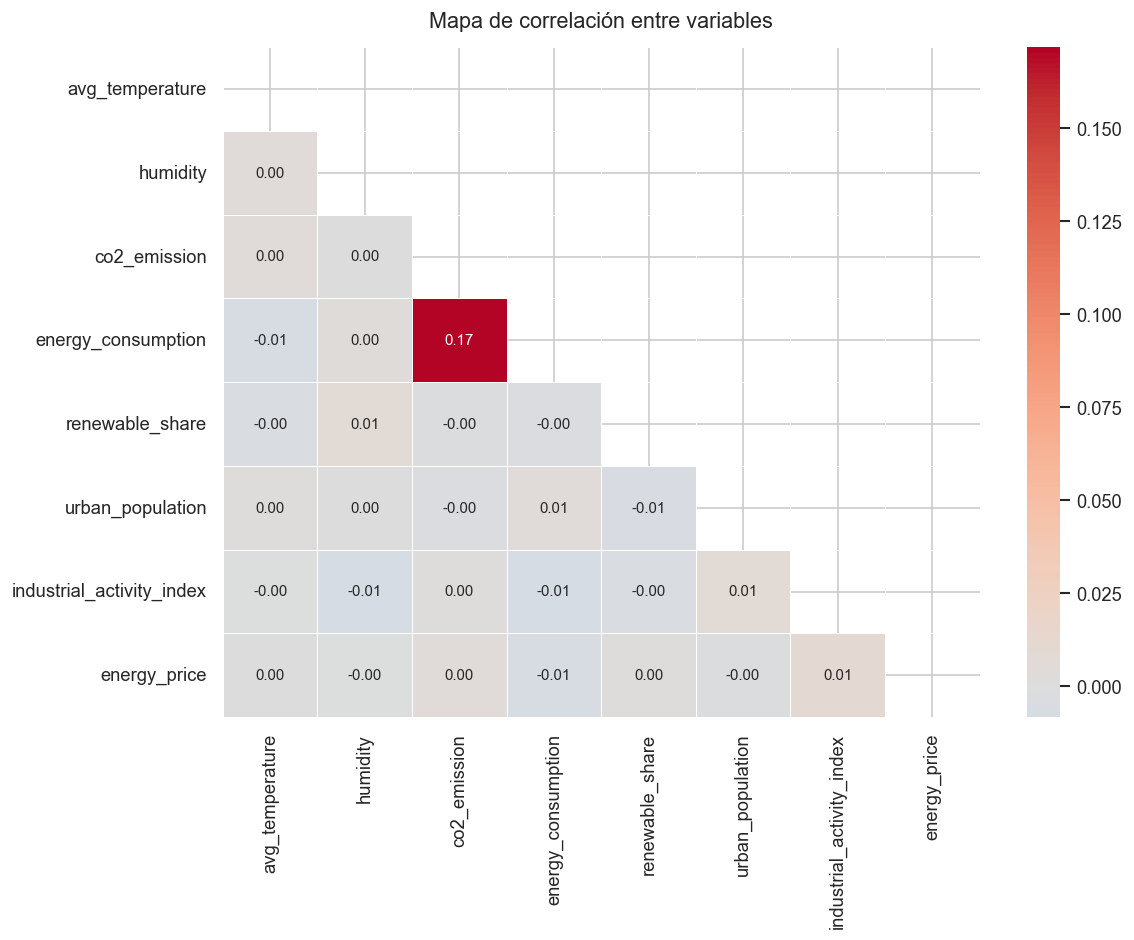

In [22]:
corr = df[variables_numericas].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    ax=ax, annot_kws={"size": 9}
)
ax.set_title("Mapa de correlación entre variables", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [23]:
# El dataset ya está limpio (sin nulos, tipos correctos)
# Lo guardamos para usarlo en los siguientes pasos
df.to_csv("../data/dataset_limpio.csv", index=False)

print("✅ Dataset limpio guardado en: data/dataset_limpio.csv")
print(f"   Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

✅ Dataset limpio guardado en: data/dataset_limpio.csv
   Filas: 36,540 | Columnas: 10
